# Numerical Simulation Laboratory - Notebook 9

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

## Exercise 09.1

The genetic algorithm is implement with two classes: 
- an `Individual` class that contains one chromosome, the mutation methods and the fitness calculation;
- a `Population` class that contains many individuals and implements the population evolution and the new generation selection.

The chromosomes are represented as vectors of integers, where each integer represents a different city. The first gene of each chromosome is fixed to $1$ to reduce the solution degeneration. Each generation is selected from the previous one with a fake roulette wheel selection, where fitter individuals are more likely to be chosen, with a law $j=\text{int}(M\times r^2)$, where $M$ is the population dimension and $r\in\mathcal{U}[0,1]$. After an individual is selected the algorithm either execute a crossover operator with probability $p_c$ (in which another parent is extracted and the two resulting children are saved to the new population) or copies the selected individual to the new population. After the selection the mutations are applied to the population with their corresponding probabilities. The algorithm keeps track of the best solution ever generated, which is returned at the end as the optimal path.

### 34 cities on a circumference

Best path length: 6.23127


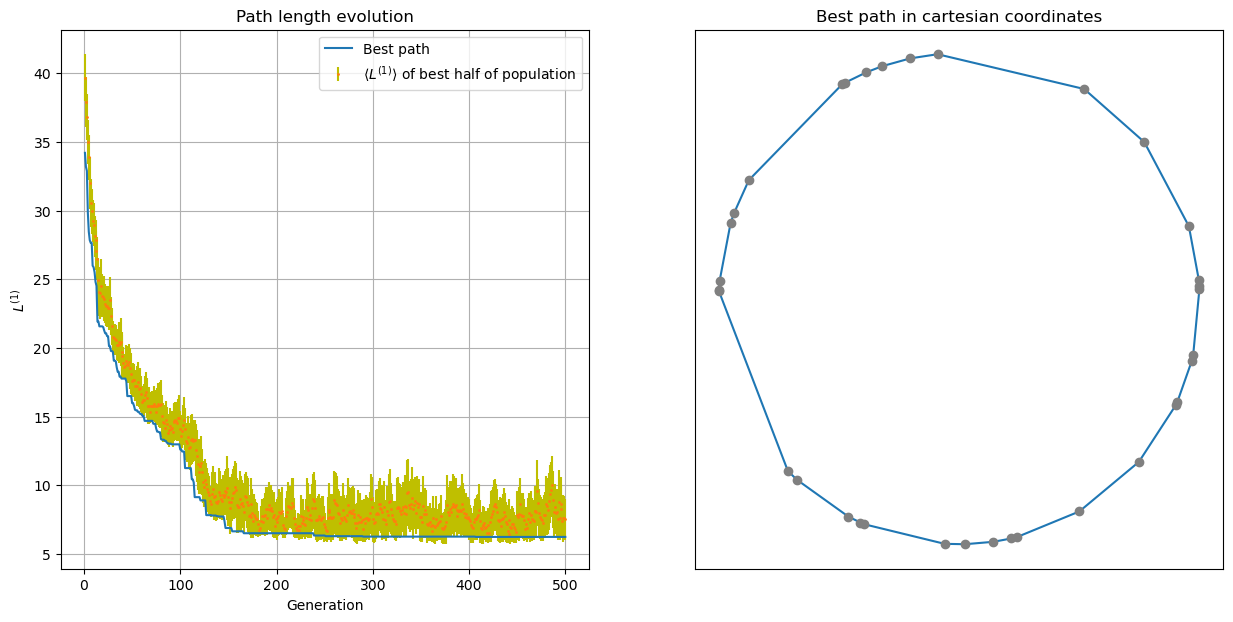

In [2]:
optimal = np.loadtxt("../09-Exercises/OUTPUT/circle_path.out", dtype=int, usecols=0) - 1
cities = np.loadtxt("../09-Exercises/OUTPUT/circle_coordinates.out", usecols=(1,2))
optimal = np.append(optimal, optimal[0]) # Add the starting point to close the path

generations, best_lengths, half_average, half_err = np.loadtxt("../09-Exercises/OUTPUT/circle_evolution.out", unpack=True)

fig, axs = plt.subplots(1, 2, figsize=(15,7))

axs[0].plot(generations, best_lengths, zorder=10, label="Best path")
axs[0].errorbar(generations, half_average, yerr=half_err, fmt="o", ecolor="y", markersize=1, label=r"$\langle L^{(1)}\rangle$ of best half of population")

axs[0].set_xlabel("Generation")
axs[0].set_ylabel("$L^{(1)}$")
axs[0].set_title("Path length evolution")
axs[0].legend()
axs[0].grid()

axs[1].plot(cities[optimal,0], cities[optimal,1])
axs[1].scatter(cities[:,0], cities[:,1], color="grey", zorder=10)
axs[1].get_xaxis().set_visible(False)
axs[1].get_yaxis().set_visible(False)
axs[1].set_title("Best path in cartesian coordinates");

print(f"Best path length: {best_lengths[-1]}")

The algorithm is able to find the optimal solution after about $500$ generations with $100$ individuals. The path length evolution shows how the best path length quickly falls until the $100$-th generation, after which each optimization takes a higher number of generations. The averages length of the best half of the population also has an initial fall, after which it starts oscillating around values higher than the optimal values. The plot also shows that the standard deviation of the best half of the population doesn't significantly decrease as the generations advance, meaning that the algorithm manages to keep the genetic diversity necessary to explore new solutions.

### 34 cities in a square

Best path length: 9.99609


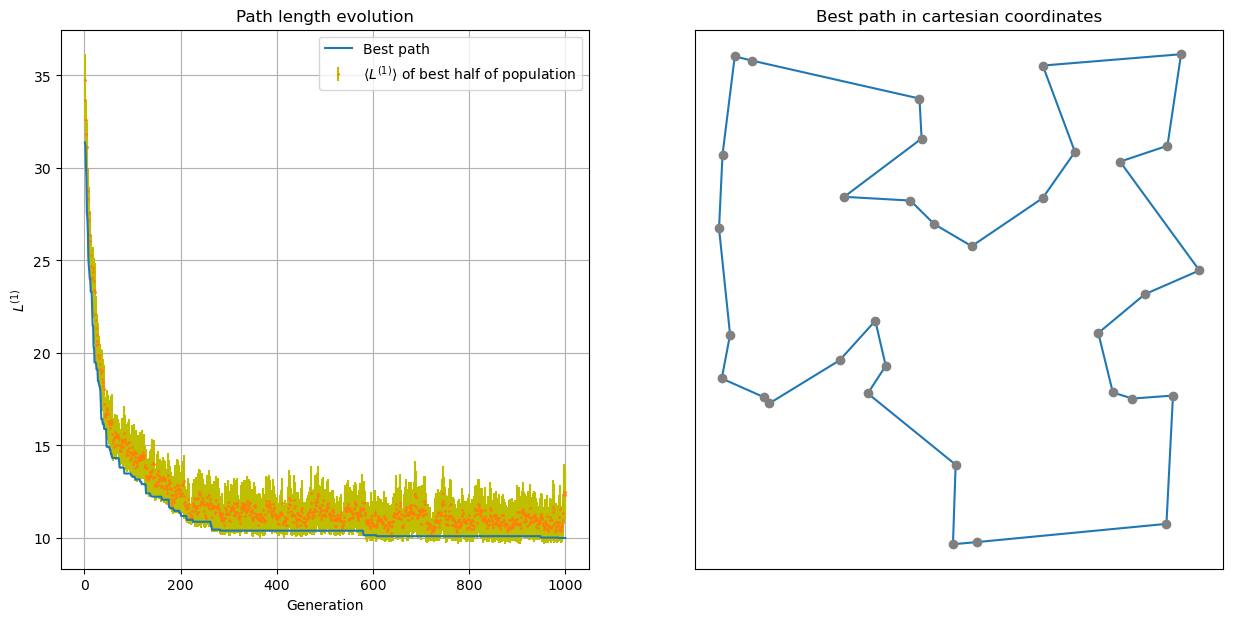

In [3]:
optimal = np.loadtxt("../09-Exercises/OUTPUT/square_path.out", dtype=int, usecols=0) - 1
cities = np.loadtxt("../09-Exercises/OUTPUT/square_coordinates.out", usecols=(1,2))
optimal = np.append(optimal, optimal[0]) # Add the starting point to close the path

generations, best_lengths, half_average, half_err = np.loadtxt("../09-Exercises/OUTPUT/square_evolution.out", unpack=True)

fig, axs = plt.subplots(1, 2, figsize=(15,7))

axs[0].plot(generations, best_lengths, zorder=10, label="Best path")
axs[0].errorbar(generations, half_average, yerr=half_err, fmt="o", ecolor="y", markersize=1, label=r"$\langle L^{(1)}\rangle$ of best half of population")

axs[0].set_xlabel("Generation")
axs[0].set_ylabel("$L^{(1)}$")
axs[0].set_title("Path length evolution")
axs[0].legend()
axs[0].grid()

axs[1].plot(cities[optimal,0], cities[optimal,1])
axs[1].scatter(cities[:,0], cities[:,1], color="grey", zorder=10)
axs[1].get_xaxis().set_visible(False)
axs[1].get_yaxis().set_visible(False)
axs[1].set_title("Best path in cartesian coordinates");

print(f"Best path length: {best_lengths[-1]}")

The algorithm is able to find the optimal solution after about $1000$ generation with $100$ individuals. By increasing the generation count this algorithm doesn't find a better solution, which means that this could be the best solution. The convergence to the optimal solution is slower than in the circumference case since it is a more complicated problem. 